# Recurrent Neural Networks (RNN)

RNNs are designed to understand sequences, where the order of things matters. A Recurrent Neural Network (RNN) is a neural network designed to process things that unfold over time (or in a sequence in general)

Ordinary neural networks look at everything all at once. But time-structured data arrives step by step.

The code idea behind RNNs is:
> The network keeps a memory of the past and updates it as new input arrives.

This memory is what we call **the hidden state** in RNN jargon. 

- At time 1, the model sees something → updates its memory
- At time 2, it sees something new → updates the same memory
- At time 3, same thing

And so on

The network does not restart at each step. That’s what makes it recurrent.

Think of it like this: when you are hearing a sentence, you do not immediately forget the first word. To get a full understanding of the sentence you need to keep track of the words as you hear them and update your understanding of the meaning of the sentence as words come in. This is exactly what the RNN is doing. 

The hidden state is not the past itself — it’s a compressed summary of the past.

Now the math behind it: 

At each time step t:
$$h_t = f(x_t, h_{t-1})$$
- $x_t$: input at time t
- $h_t$: hidden state at time t 
	​

more precisely:
$$ h_t = \phi(W_hh_{t-1} + W_xx_t + b)$$

where $\phi$ is usally something like $tanh$ so we have: $ h_t = tanh(W_hh_{t-1} + W_xx_t + b)$

- $W_hh_{t-1}$: how much the past matters
- $W_xx_t$: how much the present matters
- b: bias
- $tanh$ is supposed to keep the values from blowing up.

It is called recurrent because at each stage, the output of the model is fed back to itself (present becomes past. Memory is updated based on what the model sees now)

It is important to note that:
An RNN is not:
- a storage of all past inputs
- a database
- a time-stamped memory

It is:
- a dynamic system that evolves over time

h = 0

for x in sequence:
    h = f(h, x)


## recurrence
The internal state of the model at time t - 1 influences the internal state at time t. The model keep updating its internal/hidden state over time

simply: new state=f(**old state**,new input)

## Hidden states: 
In RNNs, hidden state is the model’s internal memory at a particular moment in time.

An RNN has one internal memory space with a fixed size.  $h_t \in \mathbb{R}^{\text{hidden\_dim}}$ 

and so everything that influences the memory (or is used in updating the memory) will have to be in the same space with the same dimension. And because the update happens in the memory:
So we project:

- input → hidden space
- previous hidden → hidden space


## 

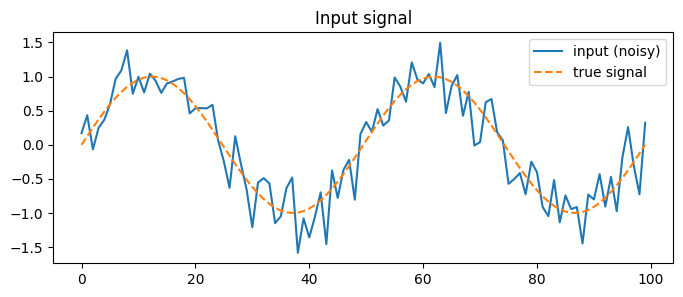

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# simulate a signal
T = 100                      # number of time steps
t = np.linspace(0, 4*np.pi, T)

x = np.sin(t)                # clean signal
x_noisy = x + 0.3 * np.random.randn(T)  # noisy input

plt.figure(figsize=(8, 3))
plt.plot(x_noisy, label="input (noisy)")
plt.plot(x, label="true signal", linestyle="--")
plt.legend()
plt.title("Input signal")
plt.show()


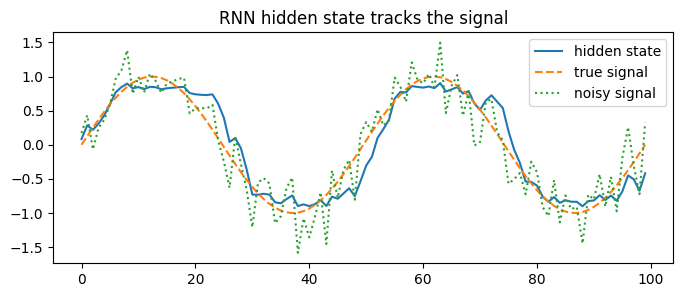

In [10]:
# Without any training, we simulate the function that the RNN is trying to implement
# RNN parameters (scalars!)
w_h = 0.9     # memory weight (past)
w_x = 0.5     # input weight (present)
b   = 0.0     # bias

def rnn_step(h_prev, x_t):
    return np.tanh(w_h * h_prev + w_x * x_t + b)


h = np.zeros(T)   # hidden state over time
h_prev = 0.0      # initial memory

for t in range(T):
    # This loop is recurrence
    # The same function is reused at every time step
    # The only thing that carries forward is h_prev
    h[t] = rnn_step(h_prev, x_noisy[t])
    h_prev = h[t]


# The hidden state is not the input.
# It’s a filtered, memory-based estimate of the input.
plt.figure(figsize=(8, 3))
plt.plot(h, label="hidden state")
plt.plot(x, linestyle="--", label="true signal")
plt.legend()
plt.plot(x_noisy, linestyle=":", label="noisy signal")
plt.legend()
plt.title("RNN hidden state tracks the signal")
plt.show()



- the hidden state is smoother than the actual noisy signal
- the hidden state is lagging with respect to the original noisy signal


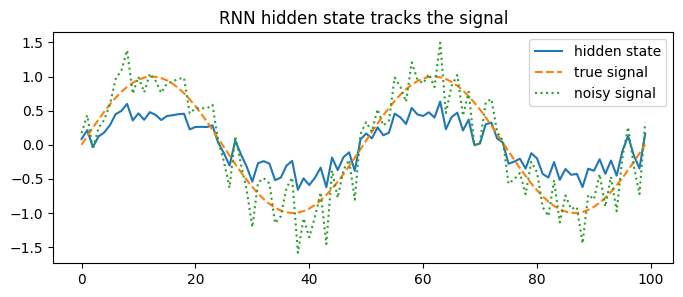

In [11]:
# now let's take a look at the role of the memory. 
# to look at the effect of memory, we set the w_h which is the weight of the previous states to 0
# Without any training, we simulate the function that the RNN is trying to implement
# RNN parameters (scalars!)
w_h = 0       # memory weight (past)
w_x = 0.5     # input weight (present)
b   = 0.0     # bias

def rnn_step(h_prev, x_t):
    return np.tanh(w_h * h_prev + w_x * x_t + b)


h = np.zeros(T)   # hidden state over time
h_prev = 0.0      # initial memory

for t in range(T):
    # This loop is recurrence
    # The same function is reused at every time step
    # The only thing that carries forward is h_prev
    h[t] = rnn_step(h_prev, x_noisy[t])
    h_prev = h[t]


# The hidden state is not the input.
# It’s a filtered, memory-based estimate of the input.
plt.figure(figsize=(8, 3))
plt.plot(h, label="hidden state")
plt.plot(x, linestyle="--", label="true signal")
plt.legend()
plt.plot(x_noisy, linestyle=":", label="noisy signal")
plt.legend()
plt.title("RNN hidden state tracks the signal")
plt.show()



- The hidden state now tracks the input instantaneously
- No temporal smoothing
- No memory

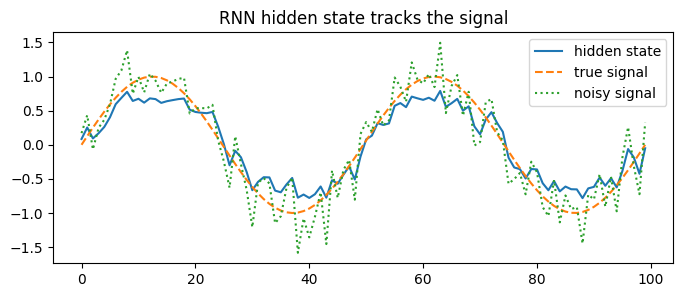

In [13]:
# Without any training, we simulate the function that the RNN is trying to implement
# RNN parameters (scalars!)
w_h = 0.5     # memory weight (past)
w_x = 0.5     # input weight (present)
b   = 0.0     # bias

def rnn_step(h_prev, x_t):
    return np.tanh(w_h * h_prev + w_x * x_t + b)


h = np.zeros(T)   # hidden state over time
h_prev = 0.0      # initial memory

for t in range(T):
    # This loop is recurrence
    # The same function is reused at every time step
    # The only thing that carries forward is h_prev
    h[t] = rnn_step(h_prev, x_noisy[t])
    h_prev = h[t]


# The hidden state is not the input.
# It’s a filtered, memory-based estimate of the input.
plt.figure(figsize=(8, 3))
plt.plot(h, label="hidden state")
plt.plot(x, linestyle="--", label="true signal")
plt.legend()
plt.plot(x_noisy, linestyle=":", label="noisy signal")
plt.legend()
plt.title("RNN hidden state tracks the signal")
plt.show()



This RNN:

- integrates information over time
- smooths noisy signals
- maintains an internal state

## The inductive biases

Definition of inductive bias: the assumptions a model makes before seeing any data. An inductive bias is the set of preferences a model has about what kinds of solutions are likely, built into its structure.

what are those built-in preferences here:

Let's take a look at the equation again:

$ h(t) = tanh(W_hh_{t-1} + W_xx(t) + b)$ 
- bias #1: time matters! What happened just before now is relevant to what happens now.
- bias #2: RNN does not store the full history
- bias #3: recent past matters more: The world has temporal continuity and decay. 
- bias #4: the dynamics are smooth (tanh)
- bias #5: Weight sharing: the same $W_h$ and $W_x$ and function (tanh in this example) are used for all the time steps

__The RNN didn’t learn to smooth the signal. It was built to smooth the signal.__

In [7]:
import torch
import torch.nn as nn

class myRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # this is where you define the architecture
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        # we use the classic update rule here:
        # h(t) = tanh(W_h*h(t-1) + W_x*x(t) + b)
        # in this update rule, W_h and W_x are learnable weights
        # which by definition (as inductive biases) remain constant over time
        # you can think of W_h and W_x as learnable affine transformations
        # NOTE that the RNN has only one internal memory space
        # and so anything that influences the memory must be in that internal memory space
        # --- Learnable weights for the update rule ---
        self.W_x = nn.Linear(input_dim, hidden_dim, bias=True)
        # W_x corresponds to the term W_x x_t + b in the math.
        # It tells the model how the current input affects memory.

        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # W_h corresponds to the term W_h h_{t-1}.
        # It tells the model how previous memory influences new memory.
        # We set bias=False here so we don't add the bias twice
        # (we already have bias in W_x).

        # it is also important to NOTE that W_x and W_h are defined as nn.Linear
        # which means they are not just a matrix
        # What is happening under the hood? for W_x
        # x_t @ W_x.weight.T + W_x.bias
        # and for self.W_h:
        # h_t @ W_h.weight.T (bias is set to False here)

        self.nonlinearity = torch.tanh
        # This is the tanh(·) in the RNN equation.
        # It keeps the hidden state bounded and introduces nonlinearity.

        # --- Learnable weights for producing outputs from hidden state ---
        self.W_y = nn.Linear(hidden_dim, output_dim, bias=True)
        # This is the readout: y_t = W_y h_t + b_y.
        # Important: the recurrence is in h_t, not y_t.
        # y_t is just what we want the model to report.

        # alternatively, we could have defined these using nn.Parameter
        # when you use nn.Linear, there are Parameters inside. In other words, 
        # nn.Linear is a container that will contain parameters
        # when we use nn.Parameter, we should also initialize them
        # on the other hand, using nn.Linear, the initialization is done automatically
        # self.W_x = nn.Parameter(torch.randn(self.input_dim, self.hidden_dim))
        # self.W_h = nn.Parameter(torch.randn(self.hidden_dim, self.hidden_dim))
        # self.b_h = nn.Parameter(torch.zeros(self.hidden_dim))

    def forward(self, x: torch.Tensor, h0: torch.Tensor | None = None):
        """
        x_seq:  Tensor of shape [batch, time, input_dim]
        h0: Optional initial hidden state of shape [batch, hidden_dim]

        Returns:
            y:  Tensor of shape [batch, time, output_dim]
            h:  Tensor of shape [batch, time, hidden_dim]  (all hidden states)
        """

        B, T, D = x.shape
        # B is batch size, T is time, D is input dim
        # NOTE that D must be equal to self.input_dim
        # you can raise an error here if that is not the case

        if D != self.input_dim:
            raise ValueError(f"Expected input_dim={self.input_dim}, got {D}")
        
        # --- Initialize hidden state (memory) ---
        if h0 is None:
            h_t = torch.zeros(B, self.hidden_dim, device=x.device, dtype=x.dtype)
            # If we don't provide an initial memory, start with zeros.
            # Conceptually: "the model begins with no information."

        else:
            # If provided, we start from a chosen initial memory state.
            h_t = h0

        h_all = []
        y_all = []
        # We'll store the hidden state and output at every time step
        # so we can visualize them and/or compute losses across time.

        # now the rollout begins
        # the recurrence happens in this loop (look we are rolling out)
        for t in range(T):
            # first get the x at time t
            x_t = x[:, t, :]
            # x_t is the input at time t for all sequences in the batch.
            # Shape: [B, input_dim]

            # now the update rule
            # NOTE this is our update rule: h(t) = tanh(W_h*h(t-1) + W_x*x(t)+b)
            # NOTE that self.W_x(x_t) is equivalent to writing:
            # W_x@x_t + b
            h_t = self.nonlinearity(self.W_h(h_t) + self.W_x(x_t))
            # This line directly matches:
            #   h_t = tanh(W_x x_t + W_h h_{t-1} + b)
            #
            # Key conceptual points:
            # 1) MEMORY: h_t depends on previous h_t (which is h_{t-1})
            # 2) RECURRENCE: we feed the hidden state forward in time
            # 3) WEIGHT SHARING: self.W_x and self.W_h are the SAME objects
            #    used for every t (same parameters reused at every step)

            # append it to h_all to keep track of it
            h_all.append(h_t)

            # now the output
            y_t = self.W_y(h_t)
            # Output readout. This does NOT feed back by default.
            # The "recurrent" part is h_t -> next h_t.

            # append it to y_all
            y_all.append(y_t)

        # Stack lists into tensors:
        h = torch.stack(h_all, dim=1)  # [B, T, hidden_dim]
        y = torch.stack(y_all, dim=1)  # [B, T, output_dim]
        return y, h
    

B, T, input_dim = 4, 10, 1
hidden_dim, output_dim = 8, 1

model = myRNN(input_dim, hidden_dim, output_dim)
x = torch.randn(B, T, input_dim)

y, h = model(x)
print("y:", y.shape)  # [4, 10, 1]
print("h:", h.shape)  # [4, 10, 8]


y: torch.Size([4, 10, 1])
h: torch.Size([4, 10, 8])


## Different types of RNNs